# Dummy baseline and logistic regression

Primary comparison: Dummy prior versus one predeclared logistic model, on identical eligible validation rows. C=1, L2, no class weighting, threshold=.5, no tuning. The two sensitivity models are not silently substituted for the primary. Unique-row validation is separately labeled because it changes the estimand. AUC is not alert recall or causal evidence.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd()/'src').is_dir() else Path.cwd().parent
assert (ROOT/'src/utils.py').exists(), 'Run from project root or notebooks/'
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import display, Image
from src import analysis
pd.set_option('display.max_colwidth', 100)


## Run this stage

The shared implementation in `src/analysis.py` produces the tables and figures. Run notebooks in numerical order on a fresh project. The source is part of the submitted, editable analysis.

In [2]:
result = analysis.modeling()
display(result)

,model,n,prevalence,threshold,roc_auc,average_precision,accuracy,balanced_accuracy,precision,recall,f1,specificity,brier,log_loss,tn,fp,fn,tp
0,Dummy prior,14088,0.261854,0.5,0.500000,0.261854,0.738146,0.500000,0.000000,0.000000,0.000000,1.000000,0.195369,0.580026,10399,0,3689,0
1,Logistic primary,14088,0.261854,0.5,0.658363,0.395351,0.737223,0.500337,0.314286,0.002982,0.005908,0.997692,0.184139,0.551734,10375,24,3678,11
2,Logistic train deduplicated,14088,0.261854,0.5,0.651689,0.387650,0.738288,0.500796,0.571429,0.002169,0.004321,0.999423,0.189844,0.569542,10393,6,3681,8
3,Logistic minimal proxy,14088,0.261854,0.5,0.642512,0.365690,0.736371,0.499847,0.244898,0.003253,0.006421,0.996442,0.185870,0.555238,10362,37,3677,12
4,Primary on unique validation rows,12453,0.238095,0.5,0.642463,0.348465,0.761262,0.500854,0.366667,0.003710,0.007346,0.997997,0.173910,0.529011,9469,19,2954,11


In [3]:
display(pd.read_csv(ROOT/'tables/model_specification.csv'))

,model,iterations,training_rows,encoded_features,C,threshold,intercept
0,Logistic primary,46,39865,39,1,0.5,-0.417083


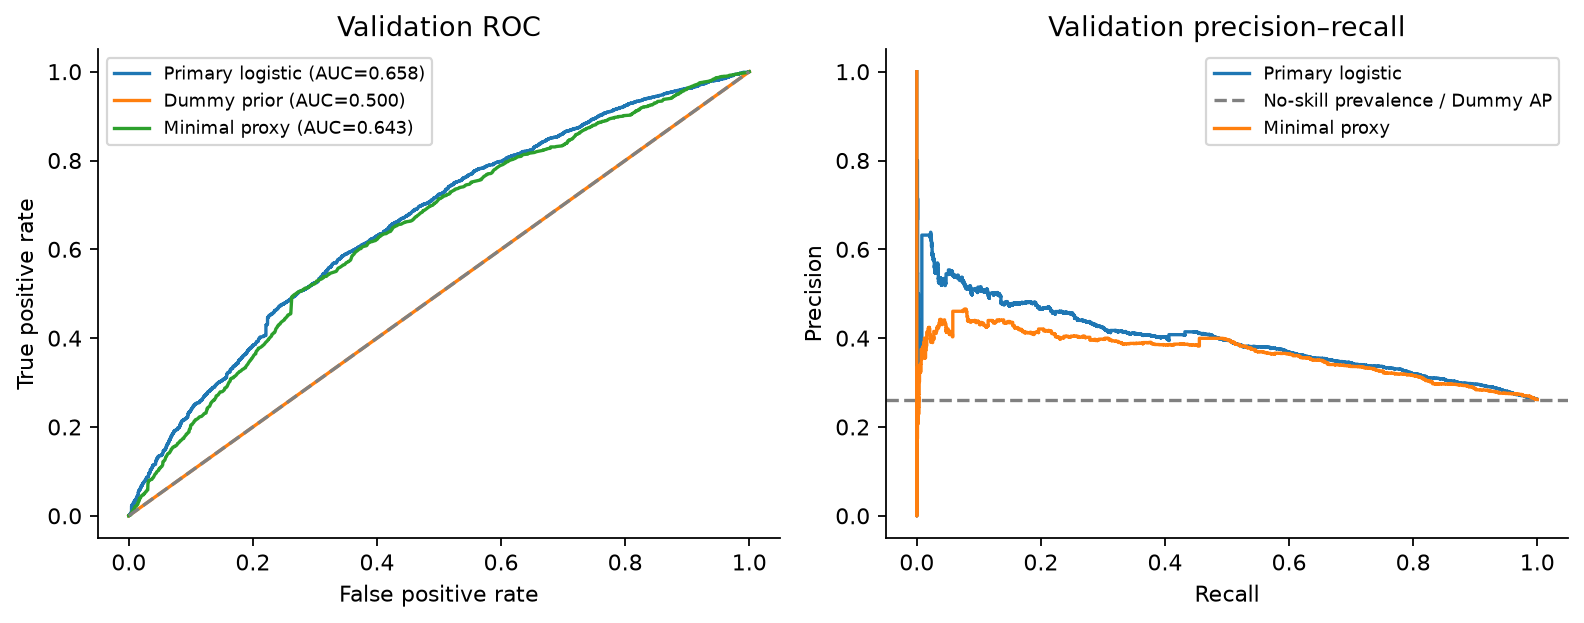

In [4]:
display(Image(filename=str(ROOT/'figures/03_validation_roc_pr.png')))

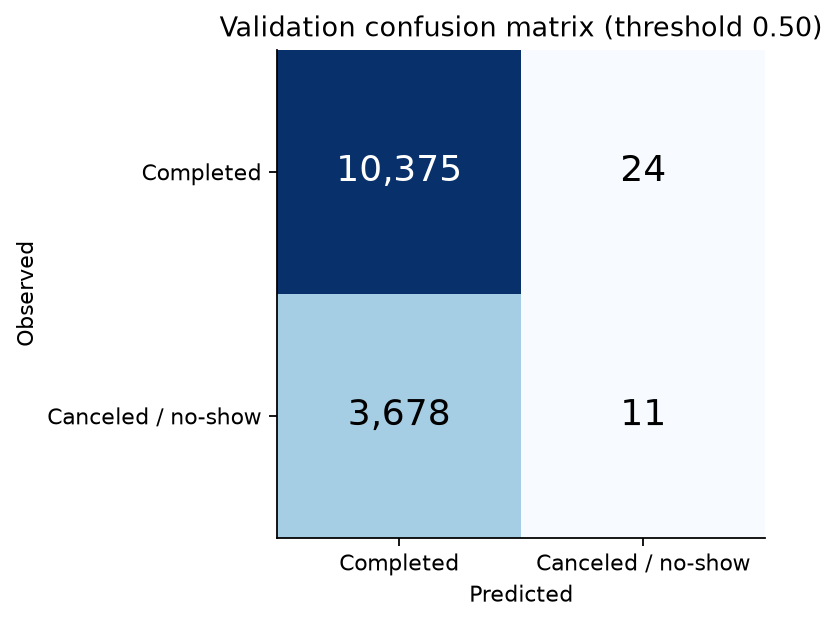

In [5]:
display(Image(filename=str(ROOT/'figures/04_confusion_matrix.png')))

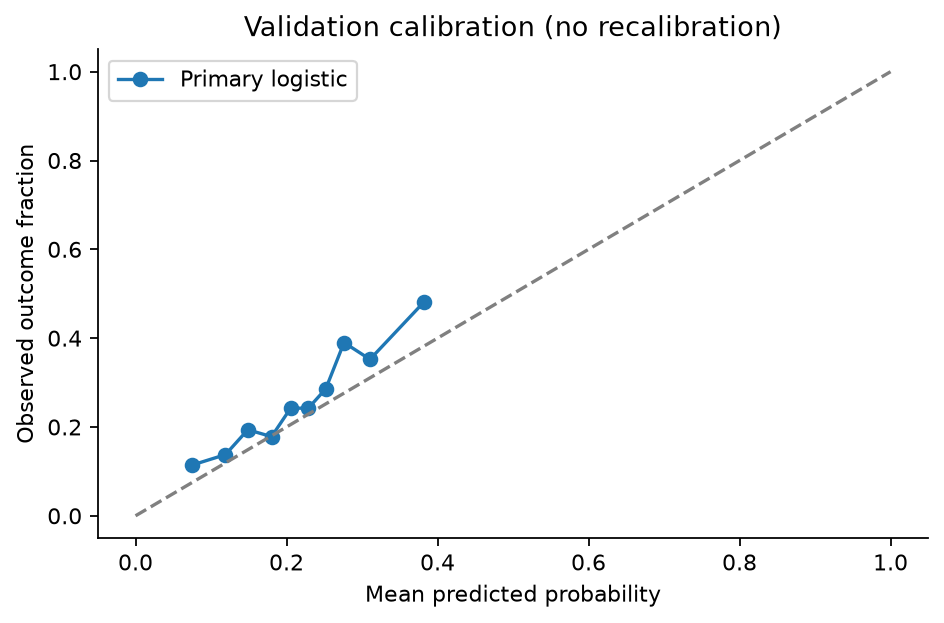

In [6]:
display(Image(filename=str(ROOT/'figures/05_calibration.png')))

## Interpretation boundary

These outputs concern a selected retrospective cohort. Review the report and leakage audit before interpreting model quality. The final holdout remains unscored.